# 🌍 Air Quality Prediction Using ARMA Model for the last quarter of 2017 -Q4 (October - November- December)

## 📌 Project Overview

This dataset contains air quality measurements collected using **low-cost environmental sensors**. The sensors monitor the concentration of airborne particulate matter (PM) along with atmospheric conditions such as **temperature** and **humidity**.

The particulate matter measurements include:

- **PM1 (P0):** Particles with diameter ≤ 1 µm  
- **PM2.5 (P2):** Particles with diameter ≤ 2.5 µm  
- **PM10 (P1):** Particles with diameter ≤ 10 µm  

In addition, the dataset includes:

- Sensor type  
- Date and time of measurements  
- Location information  
- Temperature (°C)  
- Humidity (%)  

The data is stored in **CSV format** and can be accessed using tools such as:

- Microsoft Excel  
- Google Sheets  
- LibreOffice Calc  
- Python (Pandas)  

---

## 🎯 Objective

The main objective of this project is to build an **AR (AutoRegressive)** and **ARMA (AutoRegressive Moving Average)** model to predict **PM2.5 concentrations** using historical sensor readings.

Since PM2.5 values are recorded sequentially over time, this problem can be treated as a **time series forecasting task**.

---

## 🔎 Dataset Variables

| Variable | Description |
|---|---|
| P0 | PM1 concentration |
| P2 | PM2.5 concentration *(Target Variable)* |
| P1 | PM10 concentration |
| Temperature | Temperature in °C |
| Humidity | Relative Humidity (%) |

---

This project also demonstrates the use of **time series modeling techniques** for environmental sensor data analysis.

# Project workflow
## Prepare data
    - Import
    - Explore
    - Split
## Model building
    - Baseline (dump model)
    - Iterate 
    _ Evaluate
## Communicating Results        

In [37]:
import pandas as pd 
import numpy as np 
import matplotlib.pyplot as plt 
import seaborn as sns 
import plotly_express as px
%load_ext autoreload
%autoreload 2


The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [38]:
# read the data of october
df_october = pd.read_csv("../data/raw/october_2017_sensor_data_archive.csv", sep=";", header=None)

df_october.columns = [
    "sensor_id", "sensor_type", "location",
    "lat", "lon", "timestamp",
    "value_type", "value"
]

df_october.head()


,sensor_id,sensor_type,location,lat,lon,timestamp,value_type,value
0,sensor_id,sensor_type,location,lat,lon,timestamp,value_type,value
1,28,DHT22,8,-1.306,36.733,2017-10-01T04:26:43.879246+00:00,humidity,72.30
2,28,DHT22,8,-1.306,36.733,2017-10-01T04:26:43.879246+00:00,temperature,18.00
3,27,SDS011,8,-1.306,36.733,2017-10-01T05:11:17.796678+00:00,P2,7.70
4,27,SDS011,8,-1.306,36.733,2017-10-01T05:11:17.796678+00:00,P1,14.27


In [39]:
# dropping the duplicated column names and resetting the index
df_october = df_october.drop(df_october.index[0])
df_october = df_october.reset_index(drop=True)
df_october.head()

,sensor_id,sensor_type,location,lat,lon,timestamp,value_type,value
0,28,DHT22,8,-1.306,36.733,2017-10-01T04:26:43.879246+00:00,humidity,72.30
1,28,DHT22,8,-1.306,36.733,2017-10-01T04:26:43.879246+00:00,temperature,18.00
2,27,SDS011,8,-1.306,36.733,2017-10-01T05:11:17.796678+00:00,P2,7.70
3,27,SDS011,8,-1.306,36.733,2017-10-01T05:11:17.796678+00:00,P1,14.27
4,28,DHT22,8,-1.306,36.733,2017-10-01T05:11:19.439171+00:00,humidity,67.90


In [40]:
# determine which location has more observations
for i in df_october["location"].unique():
   print(f"Shape for location {i}: {df_october[df_october["location"]==i].shape}")

Shape for location 8: (25080, 8)
Shape for location 6: (1630, 8)
Shape for location 7: (31632, 8)
Shape for location 14: (18, 8)


In [41]:
df_october.info()


<class 'pandas.DataFrame'>
RangeIndex: 58360 entries, 0 to 58359
Data columns (total 8 columns):
 #   Column       Non-Null Count  Dtype
---  ------       --------------  -----
 0   sensor_id    58360 non-null  str  
 1   sensor_type  58360 non-null  str  
 2   location     58360 non-null  str  
 3   lat          58360 non-null  str  
 4   lon          58360 non-null  str  
 5   timestamp    58360 non-null  str  
 6   value_type   58360 non-null  str  
 7   value        58360 non-null  str  
dtypes: str(8)
memory usage: 3.6 MB


In [42]:
# determine which location has more P2 readings which is out target
df_p2 = df_october[df_october["value_type"]=="P2"]
df_p2.shape

(21188, 8)

In [43]:
for i in df_p2["location"].unique():
    print(f"the shape for location {i}: {df_p2[df_p2["location"]==i].shape}")

the shape for location 8: (6269, 8)
the shape for location 6: (417, 8)
the shape for location 7: (14493, 8)
the shape for location 14: (9, 8)


## The location that has more PM2.5 readings is location "7"
 filtering our original data to have only the PM2.5 reading from location "7"
 Best way for that is to makem a wrangle function for that

In [44]:
import sys
from pathlib import Path
sys.path.append(str(Path().resolve().parent))
from src.data_prep import wrangle_data

df_october = wrangle_data("../data/raw/october_2017_sensor_data_archive.csv")
df_october.head()

,P2
timestamp,
2017-10-02 10:00:00+03:00,12.702308
2017-10-02 11:00:00+03:00,10.068095
2017-10-02 12:00:00+03:00,9.879583
2017-10-02 13:00:00+03:00,8.132917
2017-10-02 14:00:00+03:00,6.377500


In [45]:
# convert index to a datetime index
df_october.index = pd.to_datetime(df_october.index)

In [46]:
df_october.head()

,P2
timestamp,
2017-10-02 10:00:00+03:00,12.702308
2017-10-02 11:00:00+03:00,10.068095
2017-10-02 12:00:00+03:00,9.879583
2017-10-02 13:00:00+03:00,8.132917
2017-10-02 14:00:00+03:00,6.377500


In [47]:
# converting the time zone to Africa/Nairobi local time
df_october.index = df_october.index.tz_convert("Africa/Nairobi")

In [48]:
df_october.head()

,P2
timestamp,
2017-10-02 10:00:00+03:00,12.702308
2017-10-02 11:00:00+03:00,10.068095
2017-10-02 12:00:00+03:00,9.879583
2017-10-02 13:00:00+03:00,8.132917
2017-10-02 14:00:00+03:00,6.377500


In [49]:
df_october.info()

<class 'pandas.DataFrame'>
DatetimeIndex: 713 entries, 2017-10-02 10:00:00+03:00 to 2017-11-01 02:00:00+03:00
Freq: h
Data columns (total 1 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   P2      713 non-null    float64
dtypes: float64(1)
memory usage: 11.1 KB


In [54]:
# convert the value of reading to float
df_october["P2"] = df_october["P2"].astype("float")
df_october.info()

<class 'pandas.DataFrame'>
DatetimeIndex: 680 entries, 2017-10-02 10:00:00+03:00 to 2017-11-01 02:00:00+03:00
Data columns (total 1 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   P2      680 non-null    float64
dtypes: float64(1)
memory usage: 10.6 KB


In [ ]:
# # rename the value columns to P2
# df_october = df_october.rename(columns={"value":"P2"})
# df_october.head()

In [55]:
df_october["P2"].describe()

count    680.000000
mean       6.524947
std        2.609602
min        1.036957
25%        4.616910
50%        6.541667
75%        7.648152
max       13.276000
Name: P2, dtype: float64

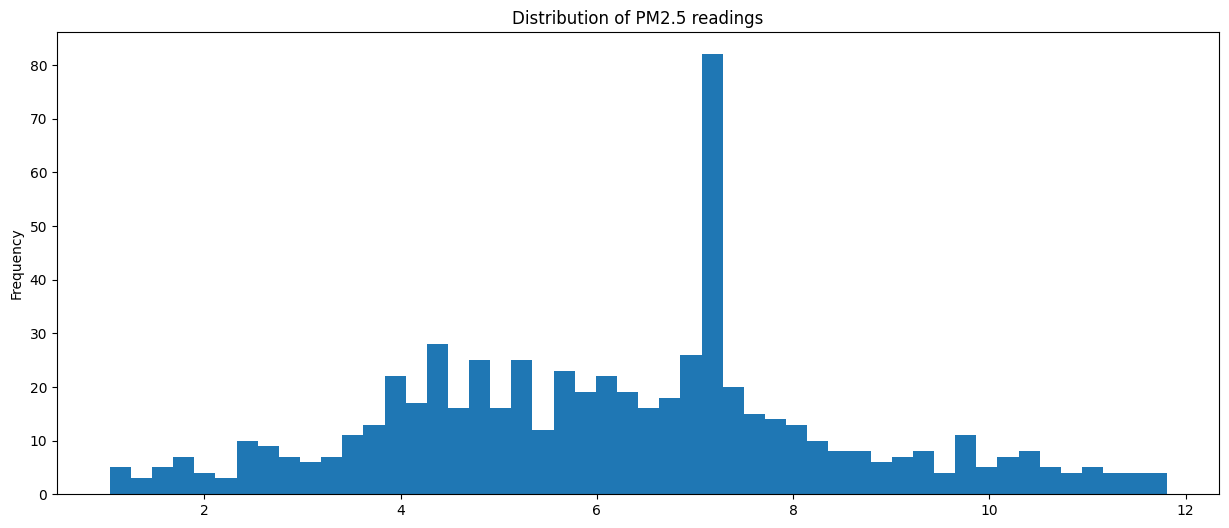

In [58]:
fig,ax = plt.subplots(figsize=(15,6))
df_october["P2"].plot(kind="hist", bins=50, ax=ax, title="Distribution of PM2.5 readings");

### It's clear that our readings data is right scewed,  
In PM2.5 data, spikes like this can come from:

🚗 Real-world events
traffic congestion peaks
industrial emissions
garbage burning
cooking/charcoal use
dust storms
local festivals or gatherings
and all this can such spikes.

<Axes: title={'center': 'Distribution of PM2.5 readings'}>

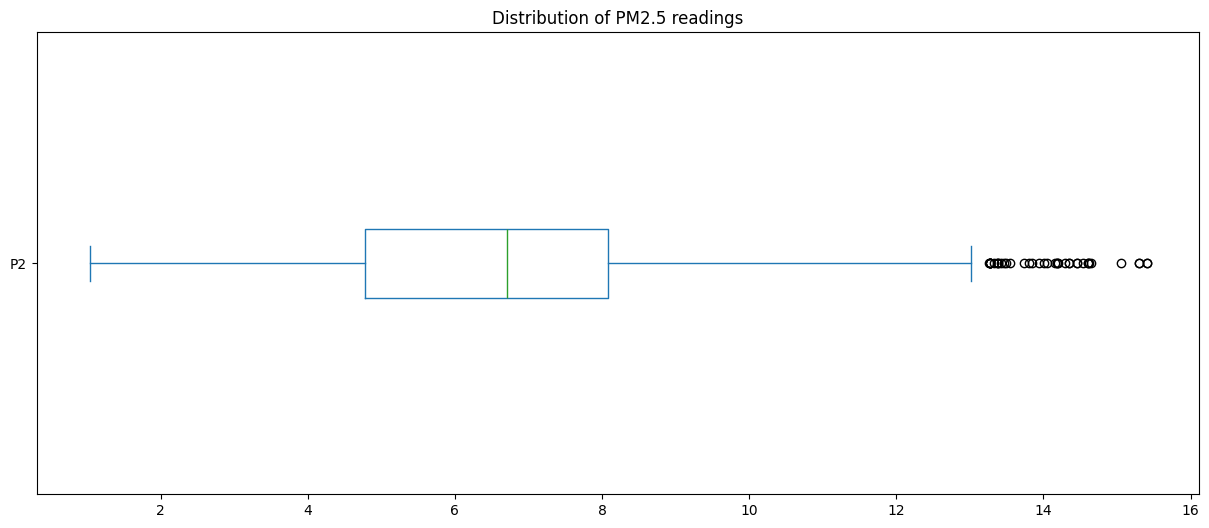

In [51]:
# checking if the P2 reading has outliers
fig,ax = plt.subplots(figsize=(15,6))
df_october["P2"].plot(kind="box", vert=False, ax=ax, title="Distribution of PM2.5 readings")

In [56]:
# Dealing with outliers
low,high = df_october["P2"].quantile([0.0, 0.95])
df_october =  df_october[df_october["P2"].between(low,high)]
df_october.max()


P2    11.805833
dtype: float64

# At this point i will edit the wrangle function to include all the steps above 
## and then load the other dataframes of the last quarter of 2017  into one big dataframe

In [57]:
from glob import glob
files = glob("../data/raw/*_2017_sensor_data_archive.csv")
frames = [wrangle_data(file) for file in files]
df = pd.concat(frames, axis=0)
df = df.sort_index()
df

,P2
timestamp,
2017-10-02 10:00:00+03:00,12.702308
2017-10-02 11:00:00+03:00,10.068095
2017-10-02 12:00:00+03:00,9.879583
2017-10-02 13:00:00+03:00,8.132917
2017-10-02 14:00:00+03:00,6.377500
...,...
2017-12-30 09:00:00+03:00,7.148095
2017-12-30 10:00:00+03:00,7.479048
2017-12-30 11:00:00+03:00,9.787778


In [59]:
df.info()

<class 'pandas.DataFrame'>
DatetimeIndex: 2140 entries, 2017-10-02 10:00:00+03:00 to 2017-12-30 13:00:00+03:00
Data columns (total 1 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   P2      2140 non-null   float64
dtypes: float64(1)
memory usage: 33.4 KB


# EDA

### One of the most powerful techniques to use with the timeseries data to find some sort of trends is the rolloing window average

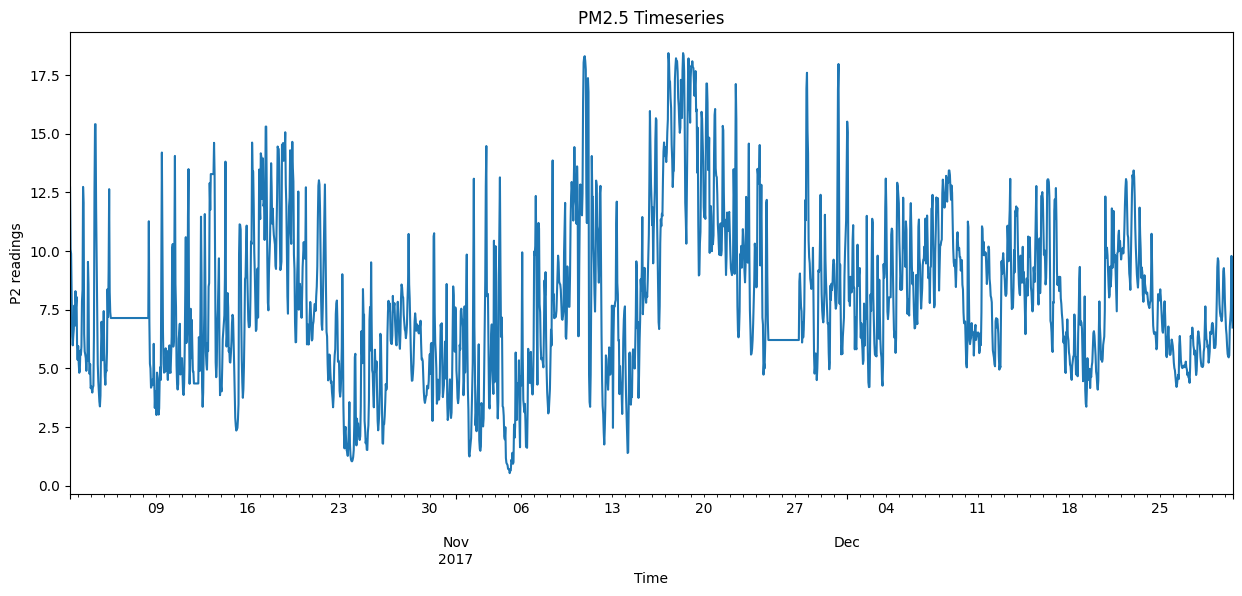

In [60]:
fig,ax = plt.subplots(figsize = (15,6))
df["P2"].plot(ax=ax)
ax.set_xlabel("Time")
ax.set_ylabel('P2 readings')
ax.set_title("PM2.5 Timeseries");
plt.savefig("../reports/figures/Timeseries.png", dpi=150)

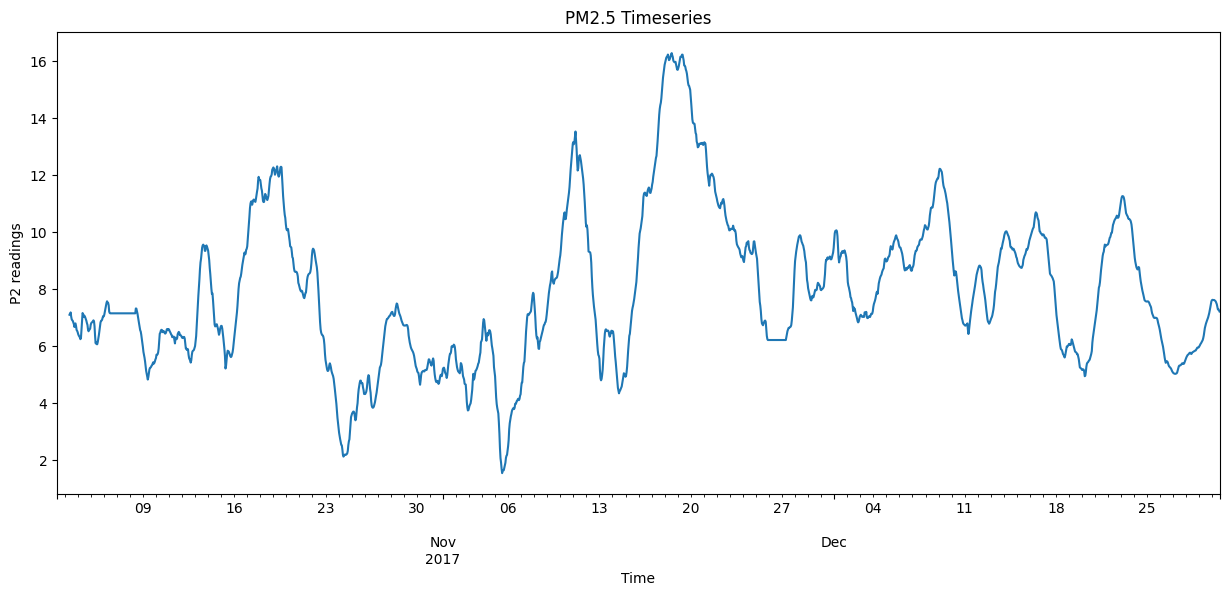

In [61]:
# daily trending
fig,ax = plt.subplots(figsize = (15,6))
df["P2"].rolling(24).mean().plot(ax=ax)
ax.set_xlabel("Time")
ax.set_ylabel('P2 readings')
ax.set_title("PM2.5 Timeseries");
plt.savefig("../reports/figures/daily_trending.png", dpi=150)

### So from the plot above it seems that we have some peaks in reading every 19th and 20th of the month so in the middle of the third week

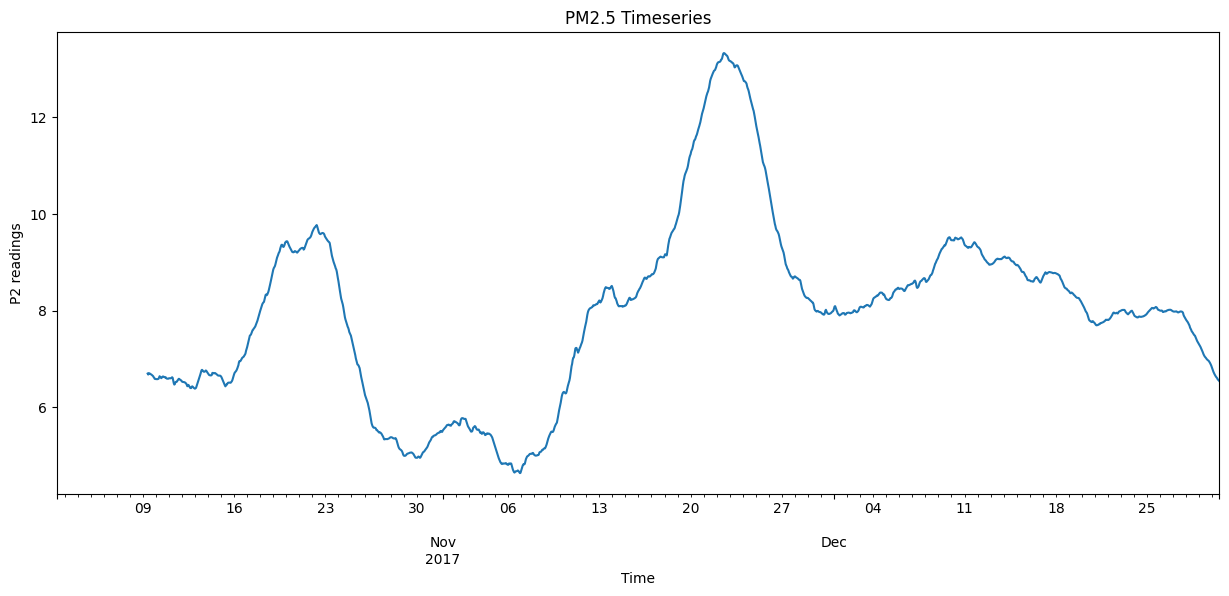

In [62]:
# weekly trending
fig,ax = plt.subplots(figsize = (15,6))
df["P2"].rolling(168).mean().plot(ax=ax)
ax.set_xlabel("Time")
ax.set_ylabel('P2 readings')
ax.set_title("PM2.5 Timeseries");
plt.savefig("../reports/figures/weekly_trending.png", dpi=150)

# Autoregressive Model (AR Model)

AR-model is a time series model that predicts the current value of a variable using its own previous values.

In other words, the model assumes that past observations contain useful information for forecasting future observations.

---

## 📘 Basic Idea

For a time series $y_t$:

$$
y_t = c + \phi_1 y_{t-1} + \phi_2 y_{t-2} + \dots + \phi_p y_{t-p} + \epsilon_t
$$

Where:

- $y_t$ → current value  
- $y_{t-1}, y_{t-2}, \dots$ → previous lag values  
- $p$ → number of lags (order of the model)  
- $\phi$ → model coefficients  
- $\epsilon_t$ → random error/noise  

---

## 📊 Example: AR(1)

An AR(1) model uses only one previous value:

$$
y_t = c + \phi_1 y_{t-1} + \epsilon_t
$$

This means:

> The current value depends mainly on the immediately previous value.

For example, if P2 pressure readings are highly correlated with their lag-1 values, an AR(1) model may work well.

---

## 📈 Relationship with PACF

The  (PACF) plot is commonly used to determine the order $p$ of an AR model.

- If the PACF sharply drops after lag $p$,
- then an AR($p$) model is often appropriate.

### Example

- Significant PACF at lags 1 and 2 only → AR(2)

In [63]:
# Vertical split
y = df["P2"]

In [64]:
# Corelation between y and its's lag of 1
y.corr(y.shift(1))

np.float64(0.9000232842399077)

In [65]:
fig = px.scatter(x=y, y=y.shift(1), title="y and it's lag_1 corelation", color=y)
fig.update_layout(xaxis_title= "Y", yaxis_title="Y lag of 1")
fig.show()

We observe a strong relationship between our target variable y (the P2 pressure reading) and its lag-1 value, which suggests that past values of the series carry useful information for prediction. However, an important question remains: how many past lags should we include as features to effectively predict P2?

To answer this, we use ACF and PACF plots.

📊 ACF (Autocorrelation Function)

Autocorrelation Function
The ACF measures the overall correlation between the time series and its past values at different lags. This includes both direct effects and indirect effects transmitted through intermediate lags.

Helps identify how long past values continue to influence the series
Useful for understanding the memory length of the system
Often used to suggest the order of a Moving Average (MA) component
📈 PACF (Partial Autocorrelation Function)

Partial Autocorrelation Function
The PACF measures the direct relationship between the series and a specific lag after removing the influence of shorter lags.

Shows which lags have unique predictive power
Helps identify the most important past time steps
Often used to select the order of an Autoregressive (AR) model
🧠 How this helps choose lag features
If the ACF decays slowly, it suggests that many past values may be relevant.
If the PACF cuts off after lag k, it suggests that only the first k lags contain meaningful direct predictive information.

👉 So, to build a feature matrix for predicting P2:

We look at the PACF to choose the most important lag features
We use ACF to understand how far back the time dependence extends

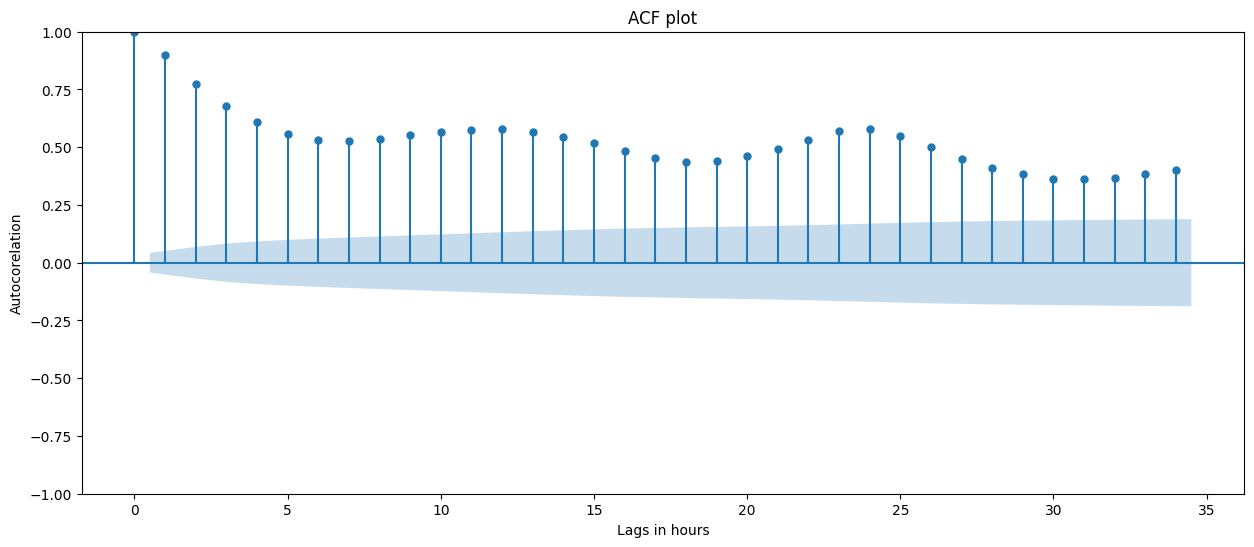

In [66]:
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
# ACF plot, autocorelation plot including the indirect relations between y and it's lags
fig,ax = plt.subplots(figsize=(15,6))
plot_acf(y, ax=ax)
ax.set_xlabel("Lags in hours")
ax.set_ylabel("Autocorelation")
ax.set_title("ACF plot");
plt.savefig("../reports/figures/acf_plot.png", dpi=150)

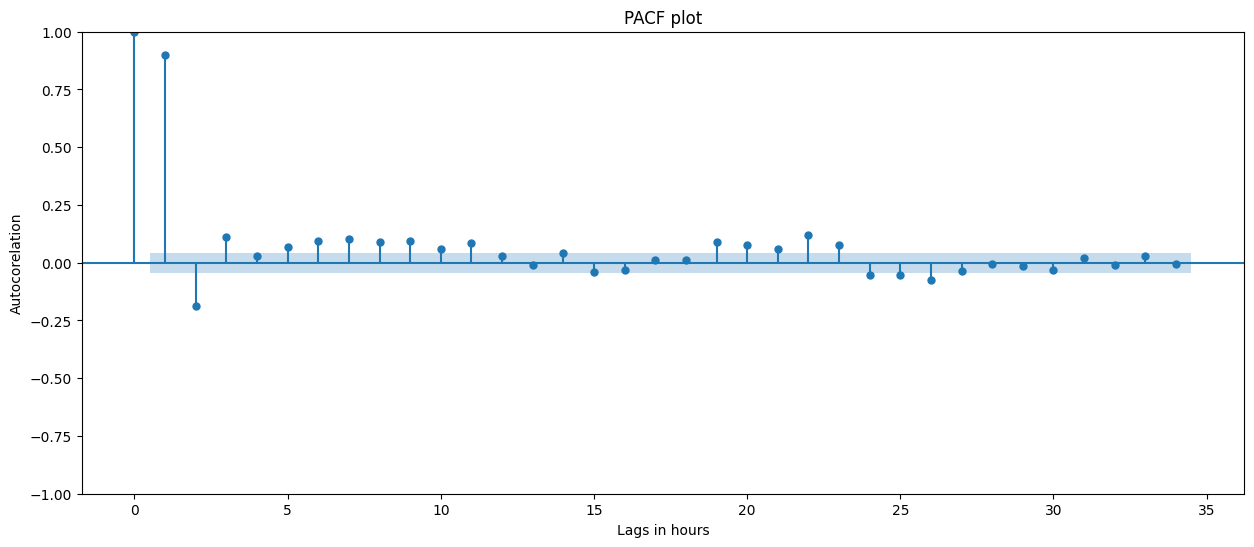

In [67]:
# Pacf plot that shows the last predictive power at which lag excatly
fig,ax = plt.subplots(figsize=(15,6))
plot_pacf(y, ax=ax)
ax.set_xlabel("Lags in hours")
ax.set_ylabel("Autocorelation")
ax.set_title("PACF plot");
plt.savefig("../reports/figures/pacf_plot.png", dpi=150)

### It seems that the the predictive power limit is at lag of 23 after this lag there is no predictive power

In [68]:
# Horizontal split of the data 
cutoff =int( len(y) * 0.8)
cutoff
y_train = y.iloc[:cutoff]
y_test = y.iloc[cutoff:]

y_train.shape, y_test.shape

((1712,), (428,))

In [69]:
from sklearn.metrics import mean_absolute_error
y_pred_baseline = [y_train.mean() for i in y_train]
mae_baseline = mean_absolute_error(y_train, y_pred_baseline)
mae_baseline

2.8602999255019745

In [70]:
# Import the autoregressive model
from statsmodels.tsa.ar_model import AutoReg
model = AutoReg(y_train, lags=23).fit()


c:\Users\m\AppData\Local\Programs\Python\Python314\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency h will be used.
  self._init_dates(dates, freq)


In [71]:
y_pred_train = model.predict().dropna()
y_pred_train

2017-10-03 09:00:00+03:00     8.604445
2017-10-03 10:00:00+03:00     8.336336
2017-10-03 11:00:00+03:00    12.598027
2017-10-03 12:00:00+03:00    10.468997
2017-10-03 13:00:00+03:00     5.226605
                               ...    
2017-12-12 13:00:00+03:00     7.442082
2017-12-12 14:00:00+03:00     6.994690
2017-12-12 15:00:00+03:00     6.502122
2017-12-12 16:00:00+03:00     5.825950
2017-12-12 17:00:00+03:00     5.433387
Freq: h, Length: 1689, dtype: float64

In [72]:
mae_training = mean_absolute_error(y_train[23:], y_pred_train)
mae_training

1.0054237729490123

### Here our training MAE beated tha baseline MAE which is a good, One more step that indicates that our linear model is performing well on the training set is the distribution of the residuals.
For linear models, residual analysis tells you whether the model assumptions are reasonable.

Key idea:

residual=y−
y
^
	​


A “good” residual pattern usually means:

residuals are centered around 0
no obvious pattern exists
variance is roughly constant
residuals are independent
distribution is approximately normal (mainly important for statistical inference)

In [73]:
y_train_residuals = y_train-y_pred_train
y_train_residuals.shape

(1712,)

In [ ]:
# Another way to predict the residuals from the Autoreg model
# Keep inj mind that exctracting the residuals this wway will automatically drop the 23 rows that contains Nulls
y_train_resid_model = model.resid
y_train_resid_model.shape

(1689,)

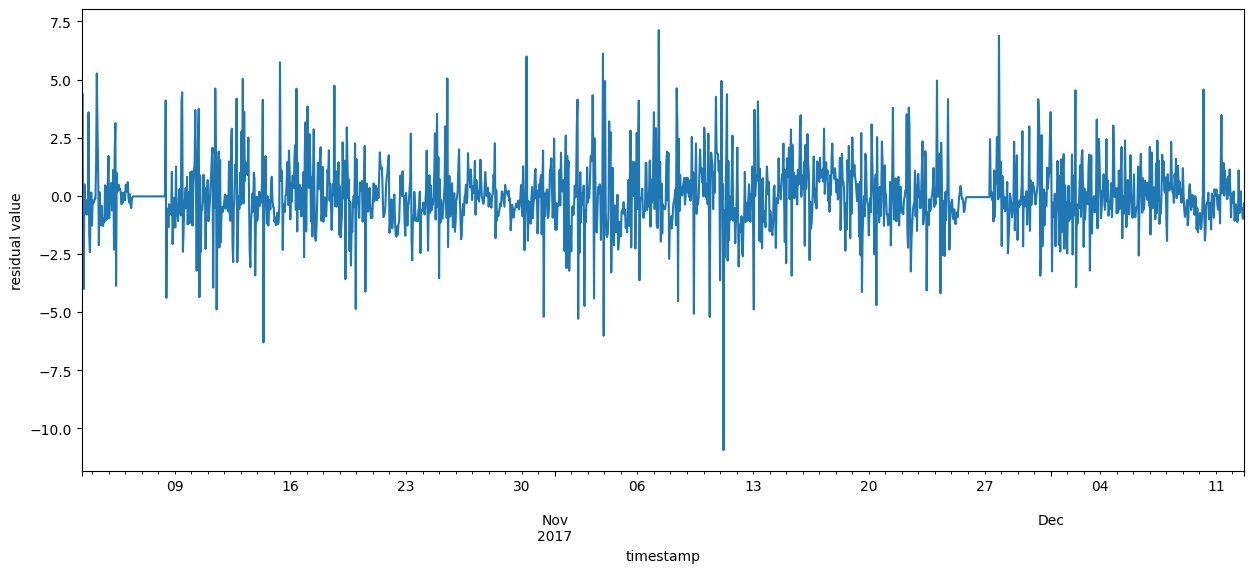

In [75]:
# Distribution of the trainig residuals
fig,ax = plt.subplots(figsize=(15,6))
# Timeseries plot of the residuals
y_train_resid_model.plot(ylabel="residual value", ax=ax);
plt.savefig("../reports/figures/residual_timeseries.png", dpi=150)



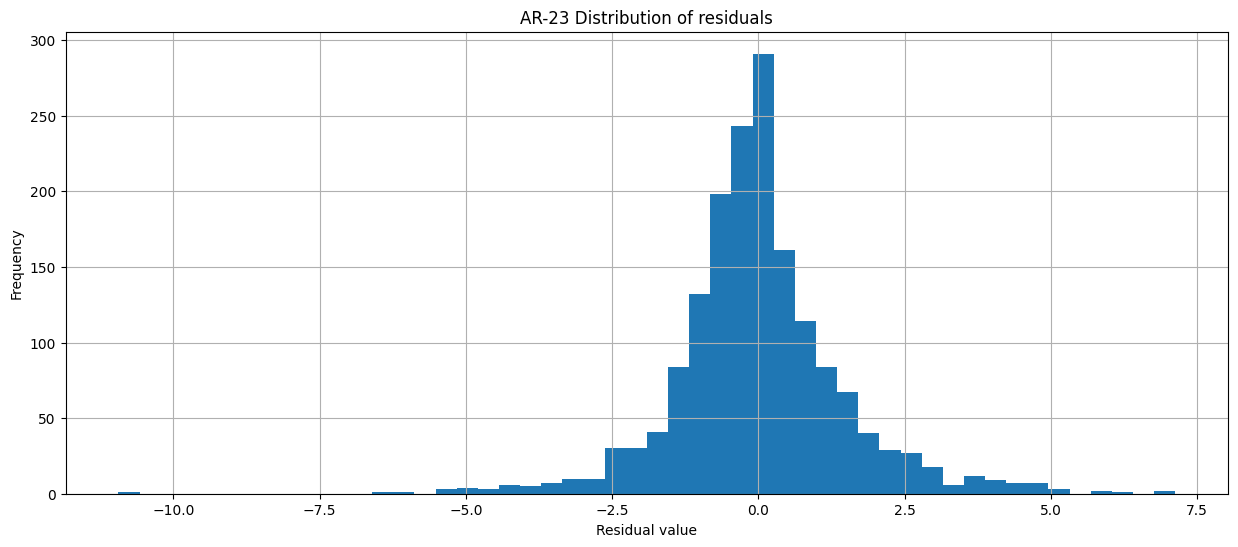

In [76]:
# Distribution of the trainig residuals
fig,ax = plt.subplots(figsize=(15,6))
y_train_resid_model.hist(ax=ax, bins=50)
plt.xlabel("Residual value")
plt.ylabel("Frequency")
plt.title("AR-23 Distribution of residuals");
plt.savefig("../reports/figures/residual_distribution.png", dpi=150)

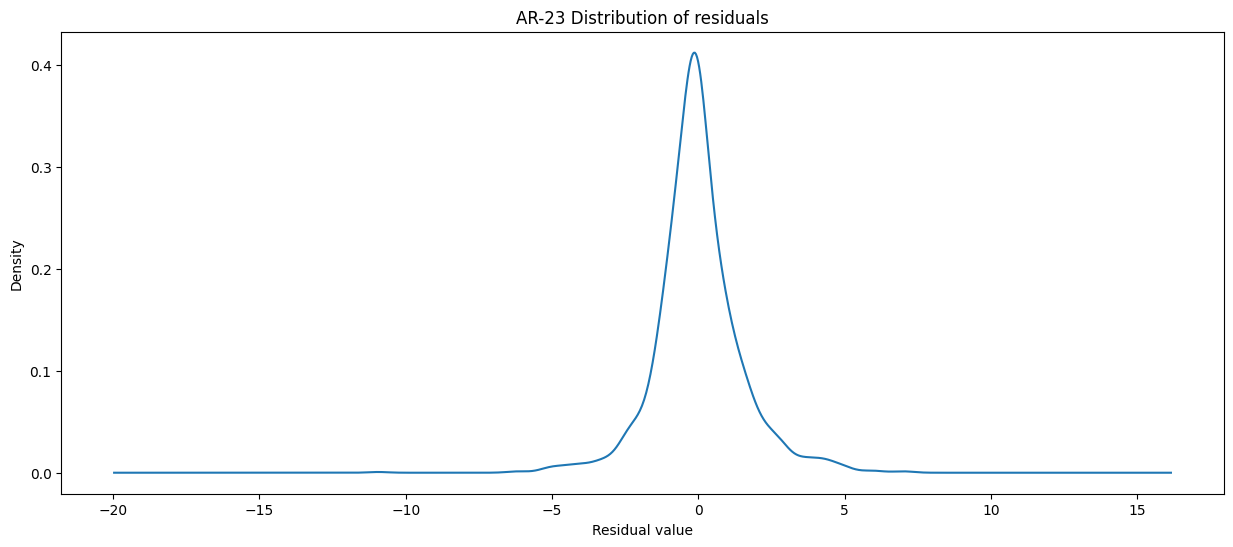

In [77]:
# Distribution of the trainig residuals [Density]
fig,ax = plt.subplots(figsize=(15,6))
y_train_resid_model.plot(kind="density",ax=ax)
plt.xlabel("Residual value")
plt.ylabel("Density")
plt.title("AR-23 Distribution of residuals");
plt.savefig("../reports/figures/residual_density.png", dpi=150)

### Residual Autocorrelation Check

Another important indicator of model quality is that the autocorrelation plot (ACF plot) of the residuals should show no significant patterns or predictive power.

This means the residuals should behave like random noise, with no correlation between current and previous errors. If residual autocorrelation exists, the model may still be missing temporal patterns in the data.

For a good autoregressive model, residuals should:
- have a mean close to zero
- show no autocorrelation
- have constant variance
- be approximately normally distributed

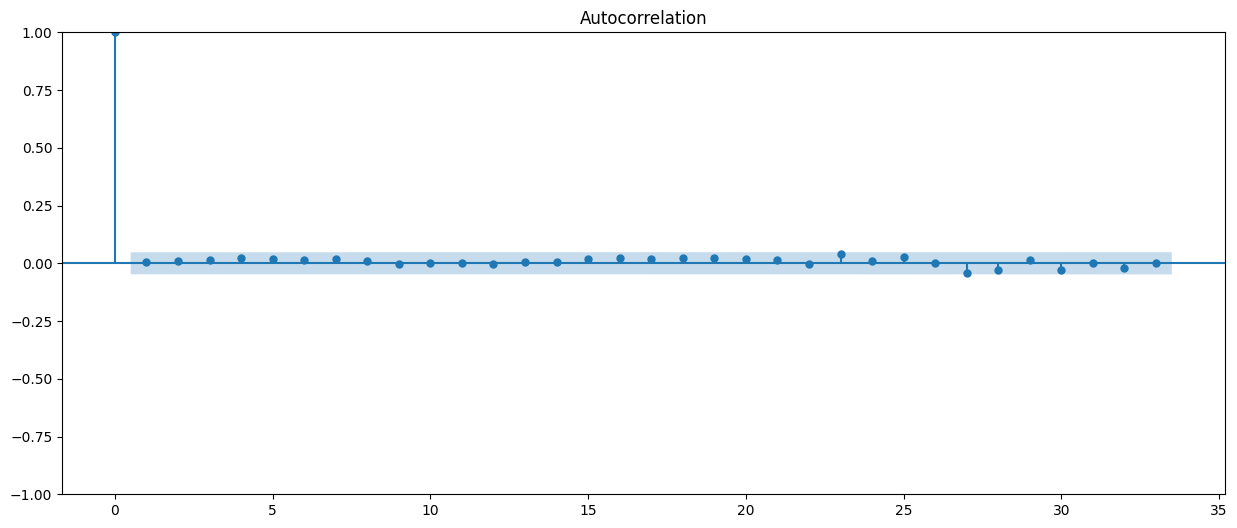

In [78]:
# acf_plot of the residuals
fig, ax = plt.subplots(figsize=(15,6))
plot_acf(y_train_resid_model, ax=ax);

## According to the plot above, That's exactly what we wanted

In [79]:
y_pred_test = model.predict(y_test.index.min(), y_test.index.max())
mae_test = mean_absolute_error(y_test, y_pred_test)
mae_test

c:\Users\m\AppData\Local\Programs\Python\Python314\Lib\site-packages\statsmodels\tsa\deterministic.py:308: UserWarning: Only PeriodIndexes, DatetimeIndexes with a frequency set, RangesIndexes, and Index with a unit increment support extending. The index is set will contain the position relative to the data length.
  fcast_index = self._extend_index(index, steps, forecast_index)


2.0398304781180583

From the mae_test above it's clear that out model is not performing well on the test set although it beated the mae_baseline

In [80]:
# Plotting a dataframe that contains the y_test and the prediction of our model on the test_set
df_pred_test = pd.DataFrame(
    {"y_test": y_test, "y_pred": y_pred_test}, index=y_test.index
)

In [81]:
fig = px.line(df_pred_test, labels={"value":"P2"})
fig.show()

## this happened becaue we used the traditional test evaluation for the linears models and we should use the walk forward validation with the AR models.

## Walk-Forward Validation for Autoregressive Models

Walk-forward validation is the preferred method for evaluating autoregressive (AR) time-series models because it mimics real forecasting conditions.

In AR models, future values are predicted using previous observations:


Instead of training the model once and predicting the entire test set at once, walk-forward validation predicts one timestep at a time:

1. Train the model on past data.
2. Predict the next timestep.
3. Compare the prediction with the true value.
4. Add the true observation to the training history.
5. Repeat for the next timestep.

This approach is better than the traditional train-test split because it:
- respects the chronological order of time-series data
- prevents leakage from future observations
- simulates real-world forecasting
- captures error accumulation over time
- adapts to changing patterns in the series

Sometimes we call such way of validation as an Expanding window validation



In [83]:

y_pred_wfv = []
history = list(y_train)
for i in range(len(y_test)):
    model = AutoReg(history, lags=23).fit()
    next_pred = model.forecast(steps=1)[0]
    y_pred_wfv.append(next_pred)
    history.append(y_test.iloc[i])

y_pred_wfv = pd.Series(y_pred_wfv, index=y_test.index)  
y_pred_wfv
  


timestamp
2017-12-12 18:00:00+03:00    5.755245
2017-12-12 19:00:00+03:00    5.690157
2017-12-12 20:00:00+03:00    7.937026
2017-12-12 21:00:00+03:00    9.735889
2017-12-12 22:00:00+03:00    8.448378
                               ...   
2017-12-30 09:00:00+03:00    7.490258
2017-12-30 10:00:00+03:00    7.420719
2017-12-30 11:00:00+03:00    7.599596
2017-12-30 12:00:00+03:00    9.710269
2017-12-30 13:00:00+03:00    6.592655
Length: 428, dtype: float64

In [84]:
mae_wfv = mean_absolute_error(y_test, y_pred_wfv)
mae_wfv

0.6296851712129139

After performing evaluation on the walk-forward validation test set, we successfully beated the baseline MAE and the training MAE.

